In [1]:
#!/usr/bin/env python3
import os
import sys
import pandas as pd

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from src.analysis_power import PowerAnalyzer
from src.analysis_serie_temporal import AnalisadorDeResiduos

In [2]:
path = "/workspaces/Remodelacao_mestrado/analysis_outputs/Potencia/2026-03-05_17-38-28_LSTM_PAZVTU/tabela.csv"
df = pd.read_csv(path, index_col = 0)

path_2 = "/workspaces/Remodelacao_mestrado/analysis_outputs/Potencia/2026-03-05_17-31-24_LSTM_PAZ/tabela.csv"
df = pd.merge(df, pd.read_csv(path_2, index_col = 0, usecols=['Date_Time', 'power_pred']), left_index=True, right_index=True, suffixes=('_PAZVTU', '_PAZ'))
df.index = pd.to_datetime(df.index)

df.rename(columns={'P1': 'power_pred_pers'}, inplace=True)

In [3]:
analyzer = PowerAnalyzer('analise_modelos')

analyzer.plot_clear_sky_day_analysis(df)
analyzer.plot_high_variability_day_analysis(df)
analyzer.plot_overcast_day_analysis(df)
#analyzer.calculate_statistical_metrics(df)
analyzer.plot_scatter_validation(df)
analyzer.plot_transient_day_analysis(df)

   ☀️ Dia selecionado (11 amostras): 2022-03-22
   ⛈️ Dia selecionado para alta variabilidade (13 amostras): 2022-01-07
   ☁️ Dia selecionado como Encoberto (11 amostras): 2022-09-26
   📈 Gerando scatter de validação estatística...
   🌦️ Dia Transiente selecionado (Alta Variabilidade Sucessiva): 2022-05-03


In [5]:
df.columns

Index(['power_real', 'power_pred_PAZVTU', 'power_pred_pers', 'error_physics',
       'power_pred_PAZ'],
      dtype='object')

In [ ]:
analisador = AnalisadorDeResiduos(df=df, col_medido='power_real', col_previsto='power_pred_PAZ')
resultados_brutos = analisador.gerar_relatorio()

📊 RELATÓRIO DE ANÁLISE DE COMPORTAMENTO DO MODELO

1️⃣ TESTE DE WHITENESS (Ljung-Box)
   p-value: 3.17510e-07
   ▶ Os resíduos NÃO SÃO Ruído Branco (Comum em persistência).

2️⃣ TESTE DE COLOR (Espectro de Frequência)
   Inclinação (Slope): -0.13
   ▶ Cor: Branco (Erros aleatórios independentes)

3️⃣ TESTE DTW (Calculando...)
   Distância DTW: 84.75


In [10]:
analisador = AnalisadorDeResiduos(df=df, col_medido='power_real', col_previsto='power_pred_pers')
resultados_brutos = analisador.gerar_relatorio()

📊 RELATÓRIO DE ANÁLISE DE COMPORTAMENTO DO MODELO

1️⃣ TESTE DE WHITENESS (Ljung-Box)
   p-value: 0.00000e+00
   ▶ Os resíduos NÃO SÃO Ruído Branco (Comum em persistência).

2️⃣ TESTE DE COLOR (Espectro de Frequência)
   Inclinação (Slope): -0.41
   ▶ Cor: Branco (Erros aleatórios independentes)

3️⃣ TESTE DTW (Calculando...)
   Distância DTW: 101.99


In [11]:
analisador = AnalisadorDeResiduos(df=df, col_medido='power_real', col_previsto='power_pred_PAZVTU')
resultados_brutos = analisador.gerar_relatorio()

📊 RELATÓRIO DE ANÁLISE DE COMPORTAMENTO DO MODELO

1️⃣ TESTE DE WHITENESS (Ljung-Box)
   p-value: 1.91222e-63
   ▶ Os resíduos NÃO SÃO Ruído Branco (Comum em persistência).

2️⃣ TESTE DE COLOR (Espectro de Frequência)
   Inclinação (Slope): -0.26
   ▶ Cor: Branco (Erros aleatórios independentes)

3️⃣ TESTE DTW (Calculando...)
   Distância DTW: 88.55


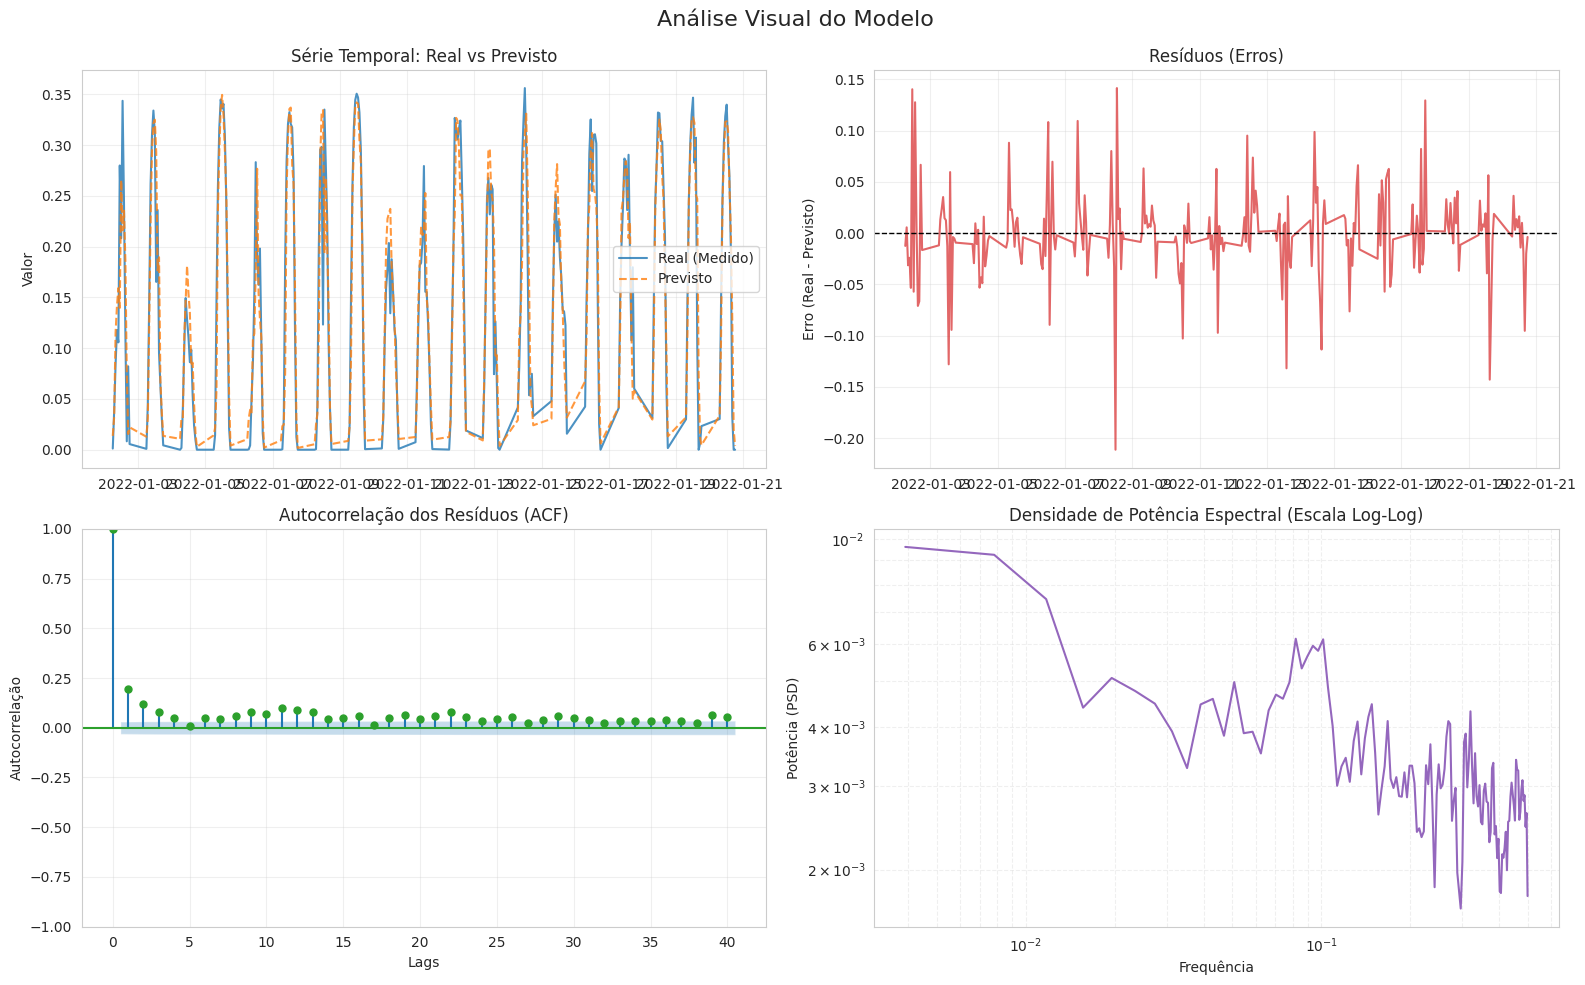

In [12]:
analisador.plotar_analises(num_amostras=240)